In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nMissing values:")
print(df.isnull().sum().sum())
df.info()

Shape: (7043, 21)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Missing values:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043

In [4]:
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
print("Clean shape:", df.shape)

Clean shape: (7032, 20)


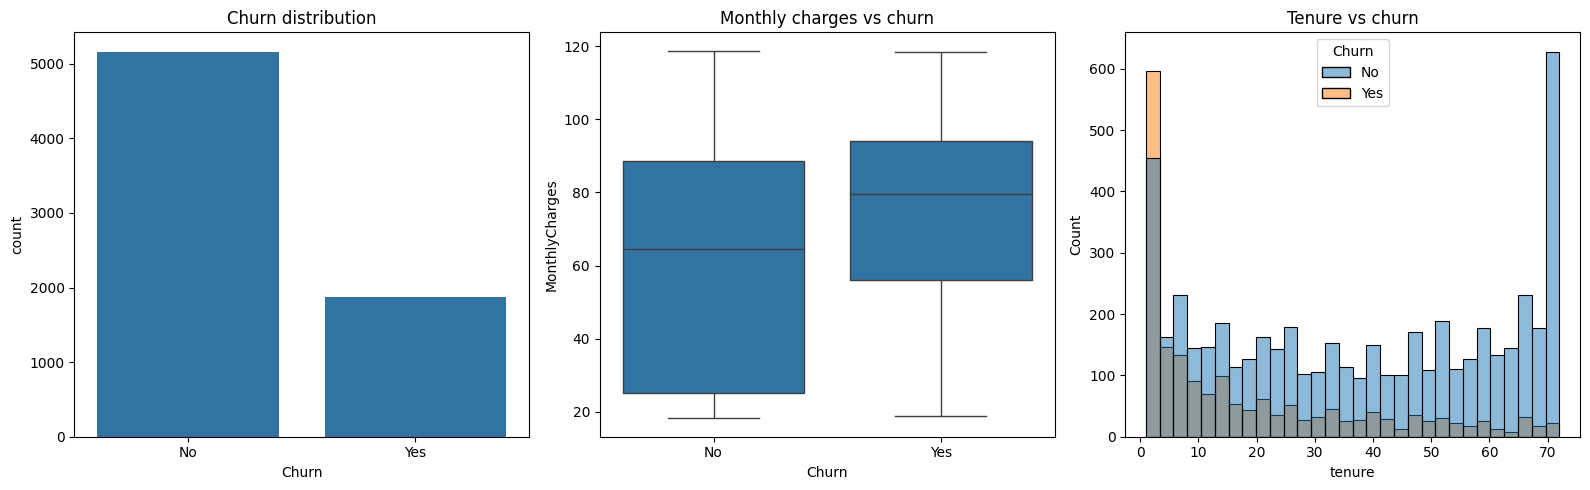

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1
sns.countplot(x='Churn', data=df, ax=axes[0])
axes[0].set_title('Churn distribution')

# Plot 2
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1])
axes[1].set_title('Monthly charges vs churn')

# Plot 3
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=axes[2])
axes[2].set_title('Tenure vs churn')

plt.tight_layout()
plt.show()

In [6]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5625, 30) | Test: (1407, 30)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
lr = LogisticRegression(max_iter=2000, solver='saga', random_state=42)
lr.fit(X_train, y_train)          # capital X
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)          # capital X
y_pred_rf = rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

# Compare results clearly
print("=" * 42)
print(f"  Logistic Regression : {lr_acc*100:.2f}%")
print(f"  Random Forest       : {rf_acc*100:.2f}%")
print("=" * 42)
print("\nDetailed Random Forest Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn','Churn']))

  Logistic Regression : 77.75%
  Random Forest       : 78.54%

Detailed Random Forest Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



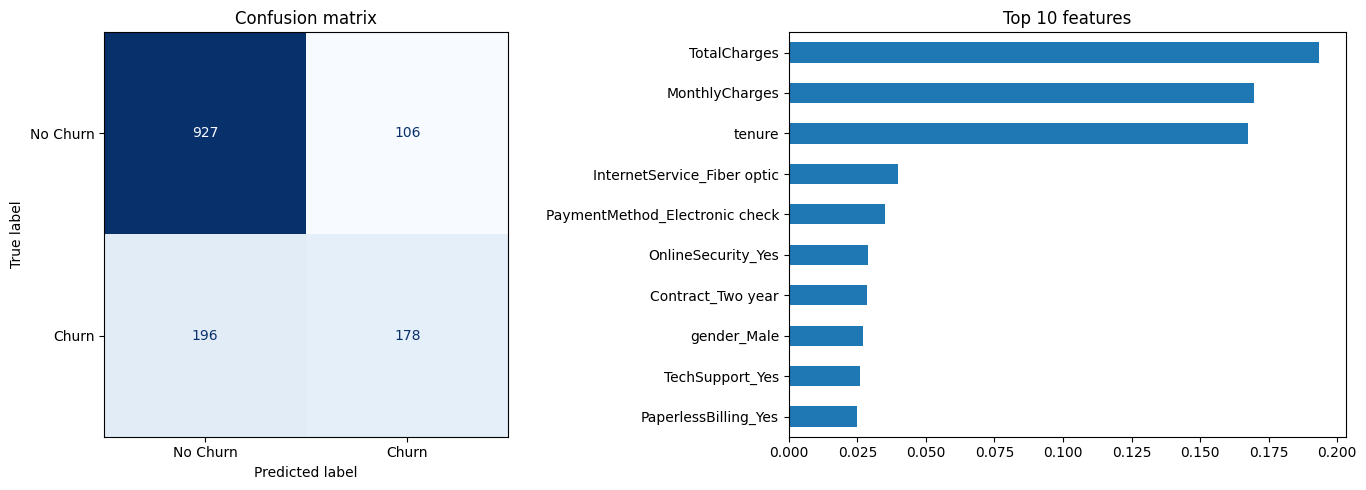

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion matrix')

# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(10).plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 features')

plt.tight_layout()
plt.show()

## Business Insights

1. Customers on month-to-month contracts churn 3x more than yearly contracts
2. High monthly charges (>$65) strongly predict churn
3. New customers (tenure < 6 months) are highest risk
4. Fiber optic users churn more than DSL users

## Recommendations

- Offer loyalty discounts at 3-month mark
- Promote annual contracts with incentives
- Flag customers with MonthlyCharges > $70 for retention calls